# Private e-processes and DP-SPRT ECDF comparisons

This notebook keeps only the empirical-CDF experiments. The DP-SPRT code here follows Algorithm 2 on the sample-average/sum scale: Laplace noise is added to the privatized running sum statistic, not directly to the log-likelihood ratio.

For Gaussian observations we clip samples before applying DP-SPRT so that the running sum has bounded sensitivity. For Bernoulli observations the running sum is already bounded.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm


# ---------- Plot style ----------

dark2 = plt.get_cmap("Dark2").colors
line_width = 3.0
label_fs = 16
title_fs = 15
tick_fs = 13
legend_fs = 12


def style_axis(ax):
    ax.grid(alpha=0.3, color="0.75", linewidth=1.0)
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("0.15")
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=tick_fs, width=1.5, color="0.15")


def ecdf_values(taus, horizon):
    x = np.arange(1, horizon + 1)
    y = np.searchsorted(np.sort(taus), x, side="right") / len(taus)
    return x, y


In [36]:
# ---------- Gaussian E* and private e-process helpers ----------

def logpdf(x, m, v):
    return norm.logpdf(x, loc=m, scale=np.sqrt(v))


def log_q_over_p_normal(x, mP, vP, mQ, vQ):
    return logpdf(x, mQ, vQ) - logpdf(x, mP, vP)


def crossing_points(level, mP, vP, mQ, vQ):
    a = 0.5 * (1 / vP - 1 / vQ)
    b = -mP / vP + mQ / vQ
    d = 0.5 * (mP**2 / vP - mQ**2 / vQ) - 0.5 * np.log(vQ / vP) - level

    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return []
        return [-d / b]

    disc = b * b - 4 * a * d
    if disc < -1e-12:
        return []
    if abs(disc) <= 1e-12:
        return [-b / (2 * a)]
    s = np.sqrt(disc)
    return sorted([(-b - s) / (2 * a), (-b + s) / (2 * a)])


def normal_prob_interval(a, b, m, v):
    sd = np.sqrt(v)
    return norm.cdf((b - m) / sd) - norm.cdf((a - m) / sd)


def prob_logratio_between(low, high, m_under, v_under, mP, vP, mQ, vQ):
    pts = [-np.inf, np.inf]
    if np.isfinite(low):
        pts += crossing_points(low, mP, vP, mQ, vQ)
    if np.isfinite(high):
        pts += crossing_points(high, mP, vP, mQ, vQ)
    pts = sorted(set(pts))

    prob = 0.0
    for a, b in zip(pts[:-1], pts[1:]):
        if np.isneginf(a):
            mid = b - 1.0
        elif np.isposinf(b):
            mid = a + 1.0
        else:
            mid = 0.5 * (a + b)

        val = log_q_over_p_normal(mid, mP, vP, mQ, vQ)
        if low <= val <= high:
            prob += normal_prob_interval(a, b, m_under, v_under)
    return prob


def f_lam_normal(lam, eps, mP, vP, mQ, vQ):
    low = np.log(lam) - eps
    high = np.log(lam) + eps

    PA = prob_logratio_between(-np.inf, low, mP, vP, mP, vP, mQ, vQ)
    PB = prob_logratio_between(high, np.inf, mP, vP, mP, vP, mQ, vQ)
    QM = prob_logratio_between(low, high, mQ, vQ, mP, vP, mQ, vQ)

    return np.exp(-eps) * PA + QM / lam + np.exp(eps) * PB


def lambda_star_normal(eps, mP, vP, mQ, vQ):
    g = lambda s: f_lam_normal(np.exp(s), eps, mP, vP, mQ, vQ) - 1
    return np.exp(brentq(g, -50, 50))


def make_logE_star_normal(eps, mP, vP, mQ, vQ):
    lam_star = lambda_star_normal(eps, mP, vP, mQ, vQ)

    def logE_star(xs):
        raw = log_q_over_p_normal(np.asarray(xs), mP, vP, mQ, vQ) - np.log(lam_star)
        return np.sum(np.clip(raw, -eps, eps))

    return logE_star, lam_star


def schedule_params(c, rho, growth_mu, grid_size=3000):
    assert rho > c, "Need rho > c."
    assert growth_mu > 0, "Need positive expected log-growth."

    lams = np.linspace(1 / rho + 1e-8, 1 / c - 1e-8, grid_size)
    C = lambda l: -np.log(1 - c**2 * l**2)
    t1 = lambda l: rho * l + rho**2 * l * C(l) / (growth_mu * (rho * l - 1) ** 2)
    vals = np.array([t1(l) for l in lams])
    lam = lams[np.argmin(vals)]
    return lam, C(lam), vals.min()


def schedule(T_local, c, rho, growth_mu):
    lam, Clam, t1_float = schedule_params(c, rho, growth_mu)
    ts = [0, int(np.ceil(t1_float))]
    j = 1
    while ts[-1] < T_local:
        nxt = int(np.ceil(rho * (lam * ts[-1] - j * Clam / growth_mu)))
        ts.append(max(nxt, ts[-1] + 1))
        j += 1
    return lam, Clam, ts


def private_log_process(xs, logE, c, rho, growth_mu, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    T_local = len(xs)
    lam, Clam, ts = schedule(T_local, c, rho, growth_mu)

    out = np.zeros(T_local)
    logEt = 0.0
    last = 0

    for j in range(1, len(ts)):
        b = ts[j]
        a = ts[j - 1]
        if b > T_local:
            break
        out[last:b - 1] = logEt
        logEt += lam * logE(xs[a:b]) + rng.laplace(0, lam * c) - Clam
        out[b - 1] = logEt
        last = b

    if last < T_local:
        out[last:] = logEt
    return out


def stopping_time_log_process(log_path, level):
    hit = np.where(log_path >= np.log(1 / level))[0]
    return hit[0] + 1 if len(hit) else len(log_path) + 1


def estimate_growth_mean(logE, mean_under, var_under=1.0, mc=100_000, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.normal(mean_under, np.sqrt(var_under), mc)
    return logE(x) / len(x)


In [37]:
# ---------- Corrected Gaussian DP-SPRT on clipped sample-sum scale ----------

def gaussian_mean_clip_bounds(mu, delta=0.01):
    radius = np.sqrt(2 * np.log(2 / delta))
    return -radius, mu + radius


def dpsprt_gaussian_mean_one_run(mu, eps, true="Q", alpha=0.05, beta=0.05,
                                 max_n=2_000, gamma=0.5, clip_delta=0.01, seed=None):
    # Algorithm-2 DP-SPRT for N(0,1) vs N(mu,1), run on clipped sample sums.
    rng = np.random.default_rng(seed)
    true_mean = 0.0 if true == "P" else mu

    clip_low, clip_high = gaussian_mean_clip_bounds(mu, clip_delta)
    Delta = clip_high - clip_low
    zeta2 = np.pi**2 / 6
    s = 2.0

    Z = rng.laplace(scale=2 * Delta / eps)
    y_scale = 4 * Delta / eps

    theta_diff = mu
    kl01 = 0.5 * mu**2
    kl10 = 0.5 * mu**2
    sum_x = 0.0

    for n in range(1, max_n + 1):
        x = rng.normal(true_mean, 1.0)
        sum_x += np.clip(x, clip_low, clip_high)

        Y = rng.laplace(scale=y_scale)
        noisy_sum = sum_x + Y

        corr_low = 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * beta)) / eps
        corr_up = 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * alpha)) / eps

        lower_sum = n * (0.0 + kl01 / theta_diff) + np.log(gamma * beta) / theta_diff - corr_low
        upper_sum = n * (mu - kl10 / theta_diff) - np.log(gamma * alpha) / theta_diff + corr_up

        if noisy_sum <= lower_sum - Z:
            return n, 0
        if noisy_sum >= upper_sum + Z:
            return n, 1

    return max_n + 1, -1


def dpsprt_gaussian_taus_Q(mu, eps, trials, max_n, alpha, beta, clip_delta=0.01, seed=0):
    rng = np.random.default_rng(seed)
    taus = []
    for _ in range(trials):
        n, _ = dpsprt_gaussian_mean_one_run(
            mu=mu,
            eps=eps,
            true="Q",
            alpha=alpha,
            beta=beta,
            max_n=max_n,
            clip_delta=clip_delta,
            seed=int(rng.integers(1e9)),
        )
        taus.append(n)
    return np.asarray(taus)


In [38]:
# ---------- Subsampled corrected Gaussian DP-SPRT on clipped sample-mean scale ----------

def dpsprt_gaussian_subsampled_mean_one_run(
    mu, eps, r, true="Q", alpha=0.05, beta=0.05,
    max_n=2_000, gamma=0.5, clip_delta=0.01, seed=None
):
    # Section-G-style DP-SPRT with Bernoulli(r) subsampling.
    # Gaussian observations are clipped to [a_delta, mu + a_delta],
    # where a_delta = sqrt(2 log(2 / delta)).
    # The stopping time is measured in total arrivals n, not included samples M_n.
    if not (0 < r <= 1):
        raise ValueError("r must be in (0, 1].")

    rng = np.random.default_rng(seed)
    true_mean = 0.0 if true == "P" else mu

    theta_diff = mu
    kl01 = 0.5 * mu**2
    kl10 = 0.5 * mu**2

    clip_low, clip_high = gaussian_mean_clip_bounds(mu, clip_delta)
    Delta = clip_high - clip_low
    zeta2 = np.pi**2 / 6
    s = 2.0

    # Section G writes the noise on the empirical-mean scale as r * Z / n
    # and r * Y_n / n. Here Z and Y_n use the clipped-sum sensitivity Delta.
    Z = rng.laplace(scale=2 * Delta / eps)
    y_scale = 4 * Delta / eps

    sampled_sum = 0.0
    sampled_count = 0

    for n in range(1, max_n + 1):
        x = rng.normal(true_mean, 1.0)
        include = rng.binomial(1, r)
        if include:
            sampled_sum += np.clip(x, clip_low, clip_high)
            sampled_count += 1

        if sampled_count == 0:
            continue

        Y = rng.laplace(scale=y_scale)
        noisy_subsample_mean = sampled_sum / sampled_count + r * Y / n

        corr_low = r * 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * beta)) / (n * eps)
        corr_up = r * 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * alpha)) / (n * eps)

        lower_mean = 0.0 + (kl01 + np.log(gamma * beta) / sampled_count) / theta_diff - corr_low
        upper_mean = mu - (kl10 + np.log(gamma * alpha) / sampled_count) / theta_diff + corr_up

        if noisy_subsample_mean <= lower_mean - r * Z / n:
            return n, 0
        if noisy_subsample_mean >= upper_mean + r * Z / n:
            return n, 1

    return max_n + 1, -1


def dpsprt_gaussian_subsampled_taus_Q(mu, eps, r, trials, max_n, alpha, beta, clip_delta=0.01, seed=0):
    rng = np.random.default_rng(seed)
    taus = []
    for _ in range(trials):
        n, _ = dpsprt_gaussian_subsampled_mean_one_run(
            mu=mu,
            eps=eps,
            r=r,
            true="Q",
            alpha=alpha,
            beta=beta,
            max_n=max_n,
            clip_delta=clip_delta,
            seed=int(rng.integers(1e9)),
        )
        taus.append(n)
    return np.asarray(taus)


# ECDF plots for DP-SPRT on Gaussian mean testing

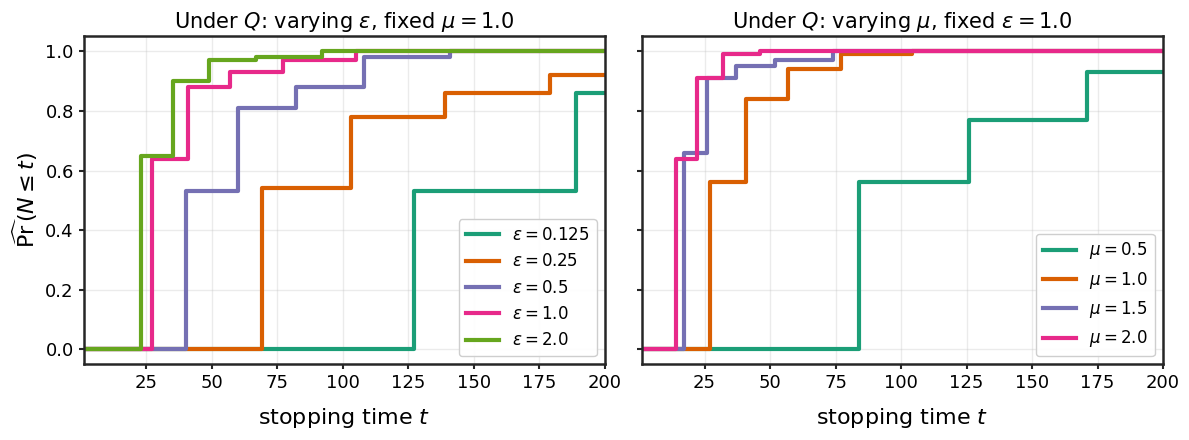

Largest empirical stopping probability under P: 0.0200 < alpha=0.05 (epsilon=0.125, mu=1.0)


In [39]:
# ---------- Gaussian: Q-only private e-process ECDF ----------

# Experiment settings for this figure.
alpha = 0.05
beta = 0.05
T = 200
R = 100
c_private = 2.0
rho_private = 5.0
mc_growth = 100_000
mu_fixed = 1.0
eps_grid = [0.125, 0.25, 0.5, 1.0, 2.0]
mu_grid = [0.5, 1.0, 1.5, 2.0]
eps_fixed = 1.0
def private_eprocess_gaussian_taus_Q(
    mu, eps, trials, horizon, alpha, beta, c, rho, mc_growth, two_sided=False, seed=0
):
    rng = np.random.default_rng(seed)
    mP, vP = 0.0, 1.0
    mQ, vQ = float(mu), 1.0

    eps_each = eps / 2 if two_sided else eps
    logE_pq, _ = make_logE_star_normal(eps_each, mP, vP, mQ, vQ)
    growth_pq = estimate_growth_mean(logE_pq, mQ, vQ, mc=mc_growth, seed=int(rng.integers(1e9)))
    growth_pq = max(growth_pq, 1e-8)

    if two_sided:
        logE_qp, _ = make_logE_star_normal(eps_each, mQ, vQ, mP, vP)
        growth_qp = estimate_growth_mean(logE_qp, mP, vP, mc=mc_growth, seed=int(rng.integers(1e9)))
        growth_qp = max(growth_qp, 1e-8)

    taus = []
    for _ in range(trials):
        xs = rng.normal(mQ, np.sqrt(vQ), horizon)
        log_path_pq = private_log_process(xs, logE_pq, c, rho, growth_pq, rng=rng)
        tau_q = stopping_time_log_process(log_path_pq, alpha)

        if two_sided:
            log_path_qp = private_log_process(xs, logE_qp, c, rho, growth_qp, rng=rng)
            tau_p = stopping_time_log_process(log_path_qp, beta)
            taus.append(min(tau_q, tau_p))
        else:
            taus.append(tau_q)

    return np.asarray(taus)


def private_eprocess_gaussian_taus_P(
    mu, eps, trials, horizon, alpha, c, rho, mc_growth, seed=0
):
    rng = np.random.default_rng(seed)
    mP, vP = 0.0, 1.0
    mQ, vQ = float(mu), 1.0
    logE_pq, _ = make_logE_star_normal(eps, mP, vP, mQ, vQ)
    growth_pq = estimate_growth_mean(logE_pq, mQ, vQ, mc=mc_growth, seed=int(rng.integers(1e9)))
    growth_pq = max(growth_pq, 1e-8)

    taus = []
    for _ in range(trials):
        xs = rng.normal(mP, np.sqrt(vP), horizon)
        log_path = private_log_process(xs, logE_pq, c, rho, growth_pq, rng=rng)
        taus.append(stopping_time_log_process(log_path, alpha))
    return np.asarray(taus)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
p_stop_under_P = []

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]
    taus_Q = private_eprocess_gaussian_taus_Q(
        mu_fixed, ee, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=False, seed=10_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_Q, T)
    ax.step(x, y, where="post", color=color, lw=line_width, label=rf"$\varepsilon={ee}$")

    taus_P = private_eprocess_gaussian_taus_P(
        mu_fixed, ee, R, T, alpha, c_private, rho_private, mc_growth,
        seed=20_000 + int(1000 * ee)
    )
    p_stop_under_P.append((rf"epsilon={ee}, mu={mu_fixed}", np.mean(taus_P <= T)))

#ax.set_xscale("log")
ax.set_xlim(1, T)
ax.set_title(rf"Under $Q$: varying $\varepsilon$, fixed $\mu={mu_fixed}$", fontsize=title_fs)
ax.set_xlabel("stopping time $t$", fontsize=label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=label_fs)
style_axis(ax)
ax.legend(fontsize=legend_fs, loc="lower right", frameon=True, edgecolor="0.8", facecolor="white", framealpha=0.95)

ax = axes[1]
for k, mm in enumerate(mu_grid):
    color = dark2[k % len(dark2)]
    taus_Q = private_eprocess_gaussian_taus_Q(
        mm, eps_fixed, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=False, seed=30_000 + int(1000 * mm)
    )
    x, y = ecdf_values(taus_Q, T)
    ax.step(x, y, where="post", color=color, lw=line_width, label=rf"$\mu={mm}$")

    taus_P = private_eprocess_gaussian_taus_P(
        mm, eps_fixed, R, T, alpha, c_private, rho_private, mc_growth,
        seed=40_000 + int(1000 * mm)
    )
    p_stop_under_P.append((rf"epsilon={eps_fixed}, mu={mm}", np.mean(taus_P <= T)))

#ax.set_xscale("log")
ax.set_xlim(1, T)
ax.set_title(rf"Under $Q$: varying $\mu$, fixed $\varepsilon={eps_fixed}$", fontsize=title_fs)
ax.set_xlabel("stopping time $t$", fontsize=label_fs, labelpad=10)
style_axis(ax)
ax.legend(fontsize=legend_fs, loc="lower right", frameon=True, edgecolor="0.8", facecolor="white", framealpha=0.95)

plt.tight_layout()
plt.savefig("gaussian_private_eprocess_Q_only_ecdf.pdf", bbox_inches="tight")
plt.show()

label_max, p_max = max(p_stop_under_P, key=lambda item: item[1])
print(f"Largest empirical stopping probability under P: {p_max:.4f} < alpha={alpha} ({label_max})")


# DP-SPRT against two-sided private e-process on Gaussians

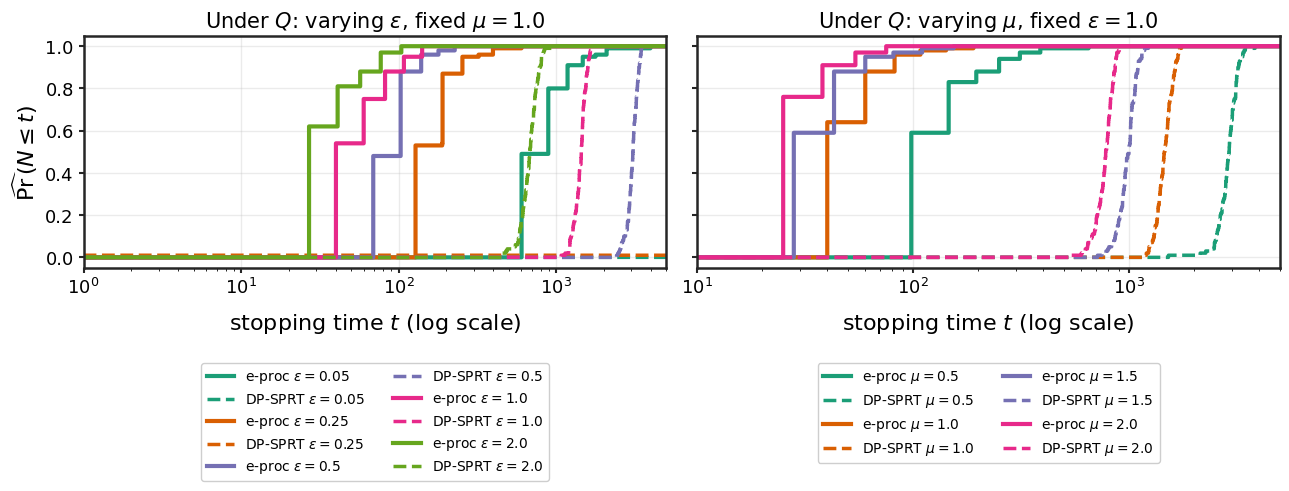

### Gaussian stopping-time summary: varying epsilon

| method | epsilon | mu | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- |
| two-sided private e-process | 0.05 | 1.0 | 880.66 | 891.0 |
| DP-SPRT | 0.05 | 1.0 | 5001.0 | 5001.0 |
| two-sided private e-process | 0.25 | 1.0 | 173.9 | 128.0 |
| DP-SPRT | 0.25 | 1.0 | 4951.0 | 5001.0 |
| two-sided private e-process | 0.5 | 1.0 | 93.56 | 103.0 |
| DP-SPRT | 0.5 | 1.0 | 3058.23 | 3075.5 |
| two-sided private e-process | 1.0 | 1.0 | 59.47 | 40.0 |
| DP-SPRT | 1.0 | 1.0 | 1428.61 | 1444.0 |
| two-sided private e-process | 2.0 | 1.0 | 38.57 | 27.0 |
| DP-SPRT | 2.0 | 1.0 | 680.15 | 680.5 |

### Gaussian stopping-time summary: varying mu

| method | epsilon | mu | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- |
| two-sided private e-process | 1.0 | 0.5 | 141.27 | 98.0 |
| DP-SPRT | 1.0 | 0.5 | 2885.63 | 2907.0 |
| two-sided private e-process | 1.0 | 1.0 | 52.04 | 40.0 |
| DP-SPRT | 1.0 | 1.0 | 1463.84 | 1460.0 |
| two-sided private e-process | 1.0 | 1.5 | 38.55 | 28.0 |
| DP-SPRT | 1.0 | 1.5 | 985.76 | 999.5 |
| two-sided private e-process | 1.0 | 2.0 | 30.19 | 25.0 |
| DP-SPRT | 1.0 | 2.0 | 774.47 | 779.5 |

In [40]:
# ---------- Gaussian: two-sided private e-process vs corrected DP-SPRT ----------

# Experiment settings for this figure.
alpha = 0.05
beta = 0.05
T = 5_000
R = 100
c_private = 2.0
rho_private = 5.0
mc_growth = 100_000
mu_fixed = 1.0
eps_grid = [0.05, 0.25, 0.5, 1.0, 2.0]
mu_grid = [0.5, 1.0, 1.5, 2.0]
eps_fixed = 1.0
clip_delta = 0.01

gaussian_summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_eprocess_gaussian_taus_Q(
        mu_fixed, ee, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=True, seed=50_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_e, T)
    gaussian_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "two-sided private e-process",
        "epsilon": ee,
        "mu": mu_fixed,
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $\varepsilon={ee}$")

    taus_s = dpsprt_gaussian_taus_Q(
        mu_fixed, ee, R, T, alpha, beta, clip_delta,
        seed=60_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_s, T)
    gaussian_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "DP-SPRT",
        "epsilon": ee,
        "mu": mu_fixed,
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $\varepsilon={ee}$")

ax.set_xscale("log")
ax.set_xlim(1, T)
ax.set_title(rf"Under $Q$: varying $\varepsilon$, fixed $\mu={mu_fixed}$", fontsize=title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=label_fs)
style_axis(ax)
ax.legend(
    fontsize=max(legend_fs - 2, 8),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

ax = axes[1]
for k, mm in enumerate(mu_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_eprocess_gaussian_taus_Q(
        mm, eps_fixed, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=True, seed=70_000 + int(1000 * mm)
    )
    x, y = ecdf_values(taus_e, T)
    gaussian_summary_rows.append({
        "experiment": "varying mu",
        "method": "two-sided private e-process",
        "epsilon": eps_fixed,
        "mu": mm,
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $\mu={mm}$")

    taus_s = dpsprt_gaussian_taus_Q(
        mm, eps_fixed, R, T, alpha, beta, clip_delta,
        seed=80_000 + int(1000 * mm)
    )
    x, y = ecdf_values(taus_s, T)
    gaussian_summary_rows.append({
        "experiment": "varying mu",
        "method": "DP-SPRT",
        "epsilon": eps_fixed,
        "mu": mm,
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $\mu={mm}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Under $Q$: varying $\mu$, fixed $\varepsilon={eps_fixed}$", fontsize=title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=label_fs, labelpad=10)
style_axis(ax)
ax.legend(
    fontsize=max(legend_fs - 2, 8),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.43)
plt.savefig("gaussian_corrected_dpsprt_vs_two_sided_eprocess_ecdf.pdf", bbox_inches="tight")
plt.show()

from IPython.display import Markdown, display


def df_to_markdown_table(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


gaussian_summary = pd.DataFrame(gaussian_summary_rows)
for experiment_name, table_df in gaussian_summary.groupby("experiment", sort=False):
    table_df = table_df[["method", "epsilon", "mu", "mean stopping time", "median stopping time"]].copy()
    table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
    table_df["median stopping time"] = table_df["median stopping time"].round(2)
    display(Markdown(f"### Gaussian stopping-time summary: {experiment_name}"))
    display(Markdown(df_to_markdown_table(table_df)))


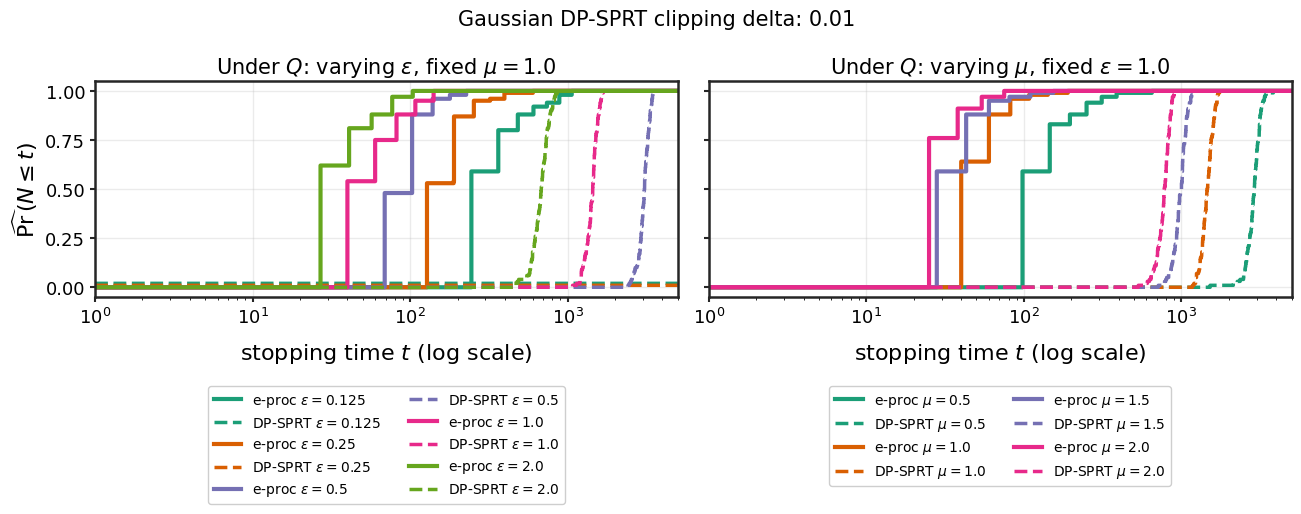

### Gaussian clipping summary: delta=0.01, varying epsilon

| delta | method | epsilon | mu | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| 0.01 | two-sided private e-process | 0.125 | 1.0 | 355.16 | 245.0 |
| 0.01 | DP-SPRT | 0.125 | 1.0 | 4901.0 | 5001.0 |
| 0.01 | two-sided private e-process | 0.25 | 1.0 | 173.9 | 128.0 |
| 0.01 | DP-SPRT | 0.25 | 1.0 | 4951.0 | 5001.0 |
| 0.01 | two-sided private e-process | 0.5 | 1.0 | 93.56 | 103.0 |
| 0.01 | DP-SPRT | 0.5 | 1.0 | 3058.23 | 3075.5 |
| 0.01 | two-sided private e-process | 1.0 | 1.0 | 59.47 | 40.0 |
| 0.01 | DP-SPRT | 1.0 | 1.0 | 1428.61 | 1444.0 |
| 0.01 | two-sided private e-process | 2.0 | 1.0 | 38.57 | 27.0 |
| 0.01 | DP-SPRT | 2.0 | 1.0 | 680.15 | 680.5 |

### Gaussian clipping summary: delta=0.01, varying mu

| delta | method | epsilon | mu | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| 0.01 | two-sided private e-process | 1.0 | 0.5 | 141.27 | 98.0 |
| 0.01 | DP-SPRT | 1.0 | 0.5 | 2885.63 | 2907.0 |
| 0.01 | two-sided private e-process | 1.0 | 1.0 | 52.04 | 40.0 |
| 0.01 | DP-SPRT | 1.0 | 1.0 | 1463.84 | 1460.0 |
| 0.01 | two-sided private e-process | 1.0 | 1.5 | 38.55 | 28.0 |
| 0.01 | DP-SPRT | 1.0 | 1.5 | 985.76 | 999.5 |
| 0.01 | two-sided private e-process | 1.0 | 2.0 | 30.19 | 25.0 |
| 0.01 | DP-SPRT | 1.0 | 2.0 | 774.47 | 779.5 |

In [41]:
# ---------- Gaussian: one comparison figure for delta-based clipping ----------

# Only the DP-SPRT curves depend on the clipping rule; the two-sided e-process curves do not.

# Experiment settings for this delta-based clipping figure.
alpha = 0.05
beta = 0.05
T = 5_000
R = 100
c_private = 2.0
rho_private = 5.0
mc_growth = 100_000
mu_fixed = 1.0
eps_grid = [0.125, 0.25, 0.5, 1.0, 2.0]
mu_grid = [0.5, 1.0, 1.5, 2.0]
eps_fixed = 1.0
clip_delta_grid = [0.01]

from IPython.display import Markdown, display


def df_to_markdown_table_clipping(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


for clip_delta in clip_delta_grid:
    clipping_summary_rows = []

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

    ax = axes[0]
    for k, ee in enumerate(eps_grid):
        color = dark2[k % len(dark2)]

        taus_e = private_eprocess_gaussian_taus_Q(
            mu_fixed, ee, R, T, alpha, beta, c_private, rho_private, mc_growth,
            two_sided=True, seed=50_000 + int(1000 * ee)
        )
        x, y = ecdf_values(taus_e, T)
        clipping_summary_rows.append({
            "experiment": "varying epsilon",
            "delta": clip_delta,
            "method": "two-sided private e-process",
            "epsilon": ee,
            "mu": mu_fixed,
            "mean stopping time": np.mean(taus_e),
            "median stopping time": np.median(taus_e),
        })
        ax.step(x, y, where="post", color=color, lw=3.0,
                label=rf"e-proc $\varepsilon={ee}$")

        taus_s = dpsprt_gaussian_taus_Q(
            mu_fixed, ee, R, T, alpha, beta, clip_delta,
            seed=60_000 + int(1000 * ee)
        )
        x, y = ecdf_values(taus_s, T)
        clipping_summary_rows.append({
            "experiment": "varying epsilon",
            "delta": clip_delta,
            "method": "DP-SPRT",
            "epsilon": ee,
            "mu": mu_fixed,
            "mean stopping time": np.mean(taus_s),
            "median stopping time": np.median(taus_s),
        })
        ax.step(x, y, where="post", color=color, lw=2.5, ls="--",
                label=rf"DP-SPRT $\varepsilon={ee}$")

    ax.set_xscale("log")
    ax.set_xlim(1, T)
    ax.set_title(
        rf"Under $Q$: varying $\varepsilon$, fixed $\mu={mu_fixed}$",
        fontsize=title_fs,
    )
    ax.set_xlabel("stopping time $t$ (log scale)", fontsize=label_fs, labelpad=10)
    ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=label_fs)
    style_axis(ax)
    ax.legend(
        fontsize=max(legend_fs - 2, 8),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.38),
        ncol=2,
        frameon=True,
        edgecolor="0.8",
        facecolor="white",
        framealpha=0.95,
    )

    ax = axes[1]
    for k, mm in enumerate(mu_grid):
        color = dark2[k % len(dark2)]

        taus_e = private_eprocess_gaussian_taus_Q(
            mm, eps_fixed, R, T, alpha, beta, c_private, rho_private, mc_growth,
            two_sided=True, seed=70_000 + int(1000 * mm)
        )
        x, y = ecdf_values(taus_e, T)
        clipping_summary_rows.append({
            "experiment": "varying mu",
            "delta": clip_delta,
            "method": "two-sided private e-process",
            "epsilon": eps_fixed,
            "mu": mm,
            "mean stopping time": np.mean(taus_e),
            "median stopping time": np.median(taus_e),
        })
        ax.step(x, y, where="post", color=color, lw=3.0,
                label=rf"e-proc $\mu={mm}$")

        taus_s = dpsprt_gaussian_taus_Q(
            mm, eps_fixed, R, T, alpha, beta, clip_delta,
            seed=80_000 + int(1000 * mm)
        )
        x, y = ecdf_values(taus_s, T)
        clipping_summary_rows.append({
            "experiment": "varying mu",
            "delta": clip_delta,
            "method": "DP-SPRT",
            "epsilon": eps_fixed,
            "mu": mm,
            "mean stopping time": np.mean(taus_s),
            "median stopping time": np.median(taus_s),
        })
        ax.step(x, y, where="post", color=color, lw=2.5, ls="--",
                label=rf"DP-SPRT $\mu={mm}$")

    ax.set_xscale("log")
    ax.set_xlim(1, T)
    ax.set_title(
        rf"Under $Q$: varying $\mu$, fixed $\varepsilon={eps_fixed}$",
        fontsize=title_fs,
    )
    ax.set_xlabel("stopping time $t$ (log scale)", fontsize=label_fs, labelpad=10)
    style_axis(ax)
    ax.legend(
        fontsize=max(legend_fs - 2, 8),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.38),
        ncol=2,
        frameon=True,
        edgecolor="0.8",
        facecolor="white",
        framealpha=0.95,
    )

    fig.suptitle(rf"Gaussian DP-SPRT clipping delta: {clip_delta}", fontsize=title_fs, y=1.03)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.43, top=0.88)

    filename = f"gaussian_corrected_dpsprt_vs_two_sided_eprocess_clip_delta_{clip_delta}.pdf"
    #plt.savefig(filename, bbox_inches="tight")
    plt.show()

    clipping_summary = pd.DataFrame(clipping_summary_rows)
    for experiment_name, table_df in clipping_summary.groupby("experiment", sort=False):
        table_df = table_df[["delta", "method", "epsilon", "mu", "mean stopping time", "median stopping time"]].copy()
        table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
        table_df["median stopping time"] = table_df["median stopping time"].round(2)
        display(Markdown(f"### Gaussian clipping summary: delta={clip_delta}, {experiment_name}"))
        display(Markdown(df_to_markdown_table_clipping(table_df)))


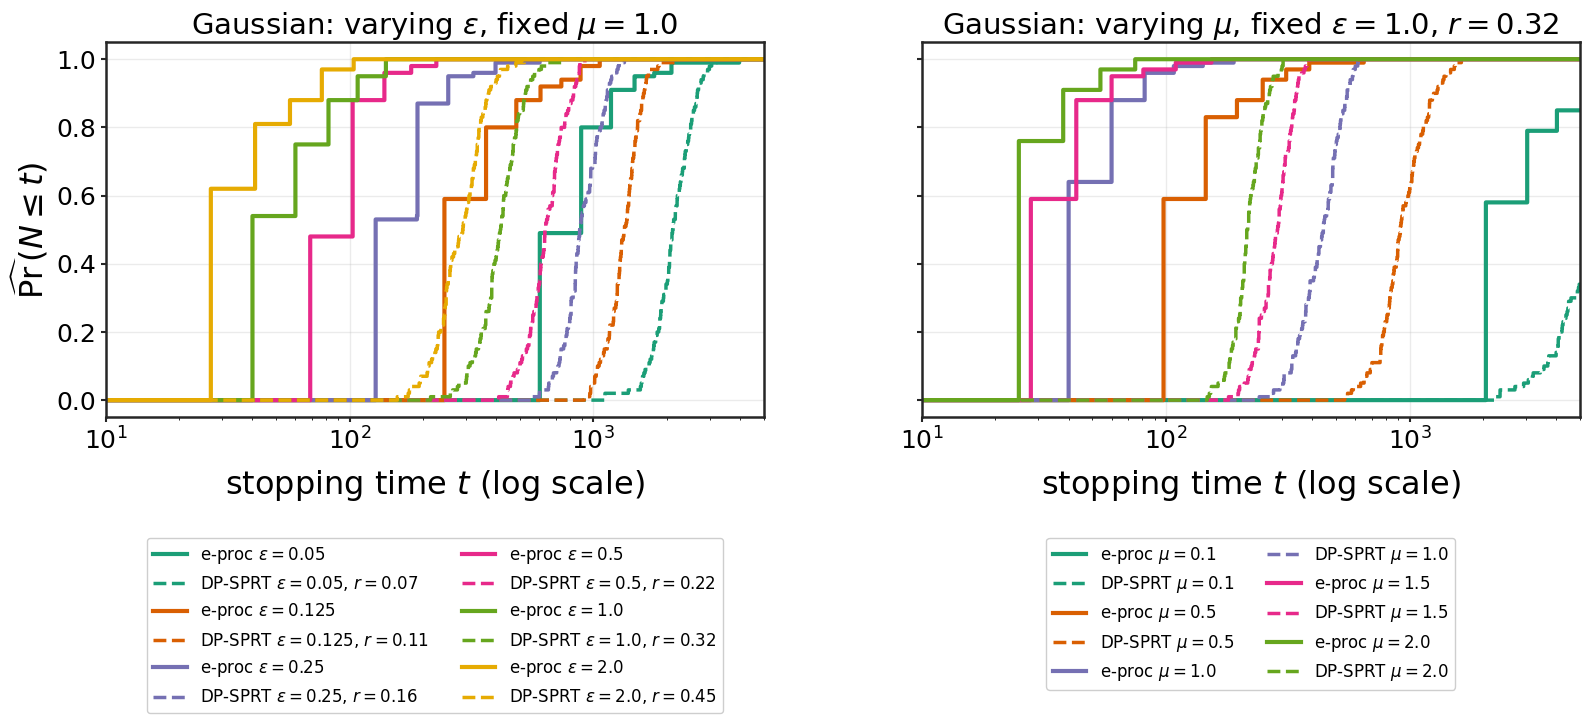

### Gaussian subsampled clipped DP-SPRT summary: varying epsilon

| method | epsilon | mu | delta | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- | --- |
| two-sided private e-process | 0.05 | 1.0 |  |  | 880.66 | 891.0 |
| subsampled clipped DP-SPRT | 0.05 | 1.0 | 0.01 | 0.071 | 2156.94 | 2116.5 |
| two-sided private e-process | 0.125 | 1.0 |  |  | 355.16 | 245.0 |
| subsampled clipped DP-SPRT | 0.125 | 1.0 | 0.01 | 0.112 | 1349.76 | 1338.0 |
| two-sided private e-process | 0.25 | 1.0 |  |  | 173.9 | 128.0 |
| subsampled clipped DP-SPRT | 0.25 | 1.0 | 0.01 | 0.158 | 915.37 | 879.0 |
| two-sided private e-process | 0.5 | 1.0 |  |  | 93.56 | 103.0 |
| subsampled clipped DP-SPRT | 0.5 | 1.0 | 0.01 | 0.224 | 651.09 | 634.5 |
| two-sided private e-process | 1.0 | 1.0 |  |  | 59.47 | 40.0 |
| subsampled clipped DP-SPRT | 1.0 | 1.0 | 0.01 | 0.316 | 421.2 | 416.0 |
| two-sided private e-process | 2.0 | 1.0 |  |  | 38.57 | 27.0 |
| subsampled clipped DP-SPRT | 2.0 | 1.0 | 0.01 | 0.447 | 292.3 | 291.5 |

### Gaussian subsampled clipped DP-SPRT summary: varying mu

| method | epsilon | mu | delta | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- | --- |
| two-sided private e-process | 1.0 | 0.1 |  |  | 2821.66 | 2056.0 |
| subsampled clipped DP-SPRT | 1.0 | 0.1 | 0.01 | 0.316 | 4621.51 | 5001.0 |
| two-sided private e-process | 1.0 | 0.5 |  |  | 141.27 | 98.0 |
| subsampled clipped DP-SPRT | 1.0 | 0.5 | 0.01 | 0.316 | 962.99 | 917.0 |
| two-sided private e-process | 1.0 | 1.0 |  |  | 52.04 | 40.0 |
| subsampled clipped DP-SPRT | 1.0 | 1.0 | 0.01 | 0.316 | 440.1 | 443.0 |
| two-sided private e-process | 1.0 | 1.5 |  |  | 38.55 | 28.0 |
| subsampled clipped DP-SPRT | 1.0 | 1.5 | 0.01 | 0.316 | 285.24 | 287.5 |
| two-sided private e-process | 1.0 | 2.0 |  |  | 30.19 | 25.0 |
| subsampled clipped DP-SPRT | 1.0 | 2.0 | 0.01 | 0.316 | 220.73 | 216.0 |

In [44]:
# ---------- Gaussian: two-sided private e-process vs subsampled clipped DP-SPRT ----------

# Experiment settings for this figure.
alpha = 0.05
beta = 0.05
T = 5_000
R = 100
c_private = 2.0
rho_private = 5.0
mc_growth = 100_000
mu_fixed = 1.0
eps_grid = [0.05, 0.125, 0.25, 0.5, 1.0, 2.0]
mu_grid = [0.1, 0.5, 1.0, 1.5, 2.0]
eps_fixed = 1.0
clip_delta = 0.01

combined_title_fs = 21
combined_label_fs = 23
combined_tick_fs = 18
combined_legend_fs = 12


def r_paper(eps):
    return min(1.0, np.sqrt(eps / 10.0))


def df_to_markdown_table_gaussian_subsampled(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


from IPython.display import Markdown, display

gaussian_subsampled_summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]
    rr = r_paper(ee)

    taus_e = private_eprocess_gaussian_taus_Q(
        mu_fixed, ee, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=True, seed=50_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_e, T)
    gaussian_subsampled_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "two-sided private e-process",
        "epsilon": ee,
        "mu": mu_fixed,
        "delta": "",
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $\varepsilon={ee}$")

    taus_s = dpsprt_gaussian_subsampled_taus_Q(
        mu_fixed, ee, rr, R, T, alpha, beta, clip_delta,
        seed=60_000 + int(1000 * ee) + int(10_000 * rr)
    )
    x, y = ecdf_values(taus_s, T)
    gaussian_subsampled_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "subsampled clipped DP-SPRT",
        "epsilon": ee,
        "mu": mu_fixed,
        "delta": clip_delta,
        "r": round(rr, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(
        x, y, where="post", color=color, lw=2.5, ls="--",
        label=rf"DP-SPRT $\varepsilon={ee}$, $r={rr:.2f}$"
    )

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Gaussian: varying $\varepsilon$, fixed $\mu={mu_fixed}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=combined_label_fs)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

ax = axes[1]
r_fixed = r_paper(eps_fixed)
for k, mm in enumerate(mu_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_eprocess_gaussian_taus_Q(
        mm, eps_fixed, R, T, alpha, beta, c_private, rho_private, mc_growth,
        two_sided=True, seed=70_000 + int(1000 * mm)
    )
    x, y = ecdf_values(taus_e, T)
    gaussian_subsampled_summary_rows.append({
        "experiment": "varying mu",
        "method": "two-sided private e-process",
        "epsilon": eps_fixed,
        "mu": mm,
        "delta": "",
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $\mu={mm}$")

    taus_s = dpsprt_gaussian_subsampled_taus_Q(
        mm, eps_fixed, r_fixed, R, T, alpha, beta, clip_delta,
        seed=80_000 + int(1000 * mm) + int(10_000 * r_fixed)
    )
    x, y = ecdf_values(taus_s, T)
    gaussian_subsampled_summary_rows.append({
        "experiment": "varying mu",
        "method": "subsampled clipped DP-SPRT",
        "epsilon": eps_fixed,
        "mu": mm,
        "delta": clip_delta,
        "r": round(r_fixed, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $\mu={mm}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Gaussian: varying $\mu$, fixed $\varepsilon={eps_fixed}$, $r={r_fixed:.2f}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.34, top=0.84, wspace=0.24)
plt.savefig("gaussian_subsampled_clipped_dpsprt_vs_two_sided_eprocess_ecdf_paper_r.pdf", bbox_inches="tight")
plt.show()

gaussian_subsampled_summary = pd.DataFrame(gaussian_subsampled_summary_rows)
for experiment_name, table_df in gaussian_subsampled_summary.groupby("experiment", sort=False):
    table_df = table_df[["method", "epsilon", "mu", "delta", "r", "mean stopping time", "median stopping time"]].copy()
    table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
    table_df["median stopping time"] = table_df["median stopping time"].round(2)
    display(Markdown(f"### Gaussian subsampled clipped DP-SPRT summary: {experiment_name}"))
    display(Markdown(df_to_markdown_table_gaussian_subsampled(table_df)))


# DP-SPRT against two-sided private e-process on Bernoullis

In [12]:
# ---------- Bernoulli E* and corrected DP-SPRT ----------

def bernoulli_log_q_over_p(x, p, q):
    x = np.asarray(x)
    return x * np.log(q / p) + (1 - x) * np.log((1 - q) / (1 - p))


def bernoulli_lambda_star(eps, p, q):
    def objective(log_lam):
        lam = np.exp(log_lam)
        e0 = np.clip(((1 - q) / (1 - p)) / lam, np.exp(-eps), np.exp(eps))
        e1 = np.clip((q / p) / lam, np.exp(-eps), np.exp(eps))
        return (1 - p) * e0 + p * e1 - 1.0
    return np.exp(brentq(objective, -50, 50))


def make_logE_star_bernoulli(eps, p, q):
    lam_star = bernoulli_lambda_star(eps, p, q)

    def logE_star(xs):
        raw = bernoulli_log_q_over_p(np.asarray(xs), p, q) - np.log(lam_star)
        return np.sum(np.clip(raw, -eps, eps))

    return logE_star, lam_star


def bernoulli_growth_mean(logE, q):
    return (1 - q) * logE([0]) + q * logE([1])


def private_eprocess_bernoulli_taus_Q(
    p, q, eps, trials, horizon, alpha, beta, c, rho, two_sided=True, seed=0
):
    rng = np.random.default_rng(seed)
    eps_each = eps / 2 if two_sided else eps
    logE_pq, _ = make_logE_star_bernoulli(eps_each, p, q)
    growth_pq = max(bernoulli_growth_mean(logE_pq, q), 1e-8)

    if two_sided:
        logE_qp, _ = make_logE_star_bernoulli(eps_each, q, p)
        growth_qp = max(bernoulli_growth_mean(logE_qp, p), 1e-8)

    taus = []
    for _ in range(trials):
        xs = rng.binomial(1, q, horizon)
        log_path_pq = private_log_process(xs, logE_pq, c, rho, growth_pq, rng=rng)
        tau_q = stopping_time_log_process(log_path_pq, alpha)

        if two_sided:
            log_path_qp = private_log_process(xs, logE_qp, c, rho, growth_qp, rng=rng)
            tau_p = stopping_time_log_process(log_path_qp, beta)
            taus.append(min(tau_q, tau_p))
        else:
            taus.append(tau_q)

    return np.asarray(taus)


def logit(p):
    return np.log(p / (1 - p))


def kl_bern(p, q):
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))


def dpsprt_bernoulli_mean_one_run(p, q, eps, true="Q", alpha=0.05, beta=0.05,
                                  max_n=2_000, gamma=0.5, seed=None):
    # Algorithm-2 DP-SPRT for Bernoulli(p) vs Bernoulli(q), on sample sums.
    rng = np.random.default_rng(seed)
    true_prob = p if true == "P" else q

    theta_diff = logit(q) - logit(p)
    kl01 = kl_bern(p, q)
    kl10 = kl_bern(q, p)

    Delta = 1.0
    zeta2 = np.pi**2 / 6
    s = 2.0

    Z = rng.laplace(scale=2 * Delta / eps)
    y_scale = 4 * Delta / eps
    sum_x = 0.0

    for n in range(1, max_n + 1):
        sum_x += rng.binomial(1, true_prob)
        Y = rng.laplace(scale=y_scale)
        noisy_sum = sum_x + Y

        corr_low = 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * beta)) / eps
        corr_up = 6 * Delta * np.log((n**s) * zeta2 / ((1 - gamma) * alpha)) / eps

        lower_sum = n * (p + kl01 / theta_diff) + np.log(gamma * beta) / theta_diff - corr_low
        upper_sum = n * (q - kl10 / theta_diff) - np.log(gamma * alpha) / theta_diff + corr_up

        if noisy_sum <= lower_sum - Z:
            return n, 0
        if noisy_sum >= upper_sum + Z:
            return n, 1

    return max_n + 1, -1


def dpsprt_bernoulli_taus_Q(p, q, eps, trials, max_n, alpha, beta, seed=0):
    rng = np.random.default_rng(seed)
    taus = []
    for _ in range(trials):
        n, _ = dpsprt_bernoulli_mean_one_run(
            p=p,
            q=q,
            eps=eps,
            true="Q",
            alpha=alpha,
            beta=beta,
            max_n=max_n,
            seed=int(rng.integers(1e9)),
        )
        taus.append(n)
    return np.asarray(taus)


In [13]:
# ---------- Bernoulli subsampled DP-SPRT helpers ----------

def dpsprt_bernoulli_subsampled_mean_one_run(
    p, q, eps, r, true="Q", alpha=0.05, beta=0.05, max_n=2_000, gamma=0.5, seed=None
):
    # Section G DP-SPRT with Bernoulli(r) subsampling.
    # The stopping time is measured in total arrivals n, not included samples M_n.
    if not (0 < r <= 1):
        raise ValueError("r must be in (0, 1].")

    rng = np.random.default_rng(seed)
    true_prob = p if true == "P" else q

    theta_diff = logit(q) - logit(p)
    kl01 = kl_bern(p, q)
    kl10 = kl_bern(q, p)

    zeta2 = np.pi**2 / 6
    s = 2.0

    # Section G writes the noise as r * Z / n and r * Y_n / n,
    # with Z ~ Lap(2/eps), Y_n ~ Lap(4/eps).
    Z = rng.laplace(scale=2 / eps)
    y_scale = 4 / eps

    sampled_sum = 0.0
    sampled_count = 0

    for n in range(1, max_n + 1):
        x = rng.binomial(1, true_prob)
        include = rng.binomial(1, r)
        if include:
            sampled_sum += x
            sampled_count += 1

        if sampled_count == 0:
            continue

        Y = rng.laplace(scale=y_scale)
        noisy_subsample_mean = sampled_sum / sampled_count + r * Y / n

        corr_low = r * 6 * np.log((n**s) * zeta2 / ((1 - gamma) * beta)) / (n * eps)
        corr_up = r * 6 * np.log((n**s) * zeta2 / ((1 - gamma) * alpha)) / (n * eps)

        lower_mean = p + (kl01 + np.log(gamma * beta) / sampled_count) / theta_diff - corr_low
        upper_mean = q - (kl10 + np.log(gamma * alpha) / sampled_count) / theta_diff + corr_up

        if noisy_subsample_mean <= lower_mean - r * Z / n:
            return n, 0
        if noisy_subsample_mean >= upper_mean + r * Z / n:
            return n, 1

    return max_n + 1, -1


def dpsprt_bernoulli_subsampled_taus_Q(p, q, eps, r, trials, max_n, alpha, beta, seed=0):
    rng = np.random.default_rng(seed)
    taus = []
    for _ in range(trials):
        n, _ = dpsprt_bernoulli_subsampled_mean_one_run(
            p=p,
            q=q,
            eps=eps,
            r=r,
            true="Q",
            alpha=alpha,
            beta=beta,
            max_n=max_n,
            seed=int(rng.integers(1e9)),
        )
        taus.append(n)
    return np.asarray(taus)


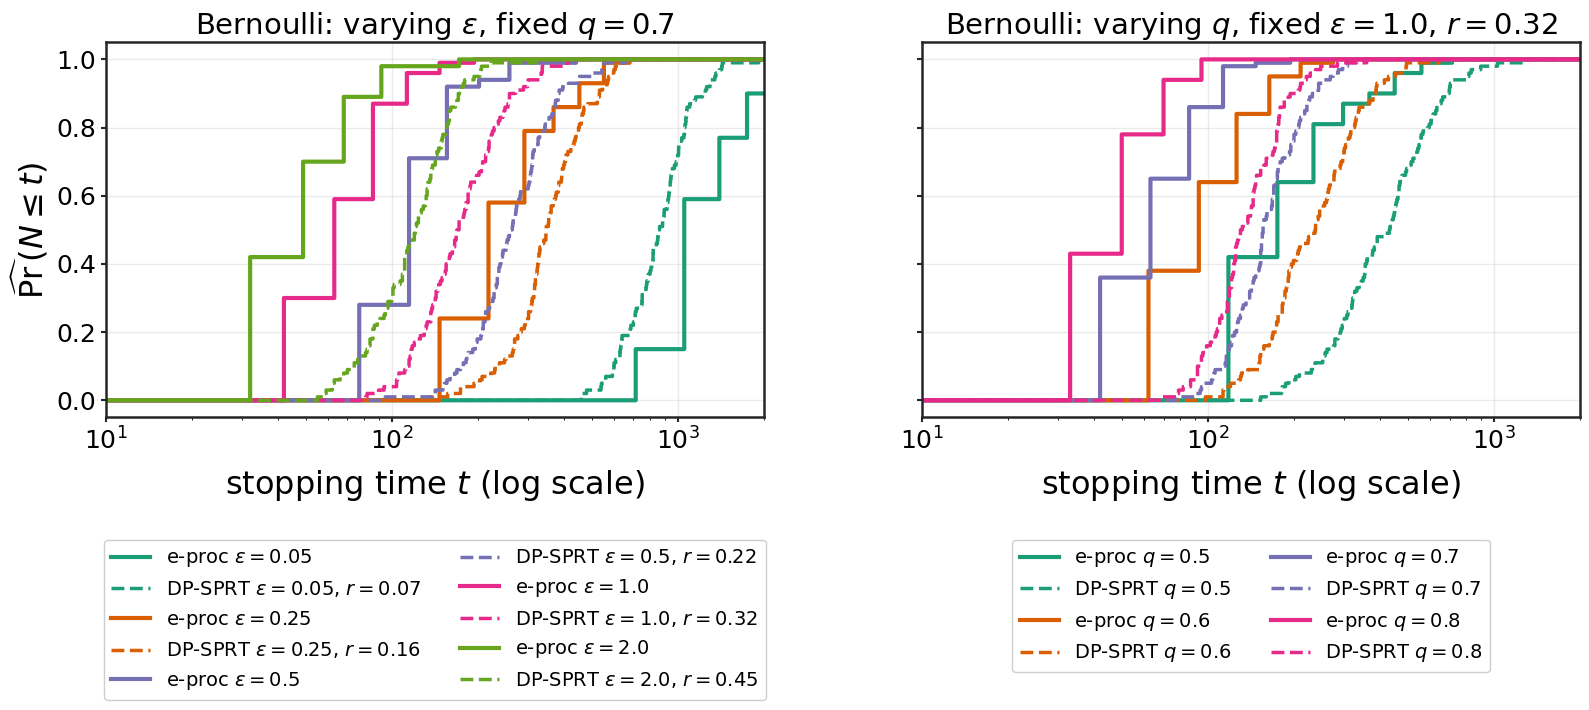

### Bernoulli stopping-time summary: varying epsilon

| method | epsilon | q | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| two-sided private e-process | 0.05 | 0.7 |  | 1249.56 | 1054.0 |
| subsampled DP-SPRT | 0.05 | 0.7 | 0.071 | 888.25 | 859.0 |
| two-sided private e-process | 0.25 | 0.7 |  | 267.89 | 218.0 |
| subsampled DP-SPRT | 0.25 | 0.7 | 0.158 | 365.91 | 347.0 |
| two-sided private e-process | 0.5 | 0.7 |  | 125.12 | 115.0 |
| subsampled DP-SPRT | 0.5 | 0.7 | 0.224 | 279.18 | 261.5 |
| two-sided private e-process | 1.0 | 0.7 |  | 71.47 | 63.0 |
| subsampled DP-SPRT | 1.0 | 0.7 | 0.316 | 184.28 | 170.5 |
| two-sided private e-process | 2.0 | 0.7 |  | 51.8 | 49.0 |
| subsampled DP-SPRT | 2.0 | 0.7 | 0.447 | 124.01 | 121.0 |

### Bernoulli stopping-time summary: varying q

| method | epsilon | q | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| two-sided private e-process | 1.0 | 0.5 |  | 207.55 | 175.0 |
| subsampled DP-SPRT | 1.0 | 0.5 | 0.316 | 445.52 | 432.0 |
| two-sided private e-process | 1.0 | 0.6 |  | 102.16 | 93.0 |
| subsampled DP-SPRT | 1.0 | 0.6 | 0.316 | 250.06 | 237.5 |
| two-sided private e-process | 1.0 | 0.7 |  | 68.42 | 63.0 |
| subsampled DP-SPRT | 1.0 | 0.7 | 0.316 | 167.26 | 156.0 |
| two-sided private e-process | 1.0 | 0.8 |  | 48.59 | 50.0 |
| subsampled DP-SPRT | 1.0 | 0.8 | 0.316 | 143.09 | 131.0 |

In [14]:
# ---------- Bernoulli: subsampled DP-SPRT with paper-suggested r(epsilon) ----------

# Experiment settings for this figure.
alpha = 0.025
beta = 0.025
T = 2_000
R = 100
c_private = 2.0
rho_private = 5.0
p0_bern = 0.3
q_fixed = 0.7
q_grid = [0.5, 0.6, 0.7, 0.8]
eps_grid = [0.05, 0.25, 0.5, 1.0, 2.0]
eps_fixed = 1.0

combined_title_fs = 21
combined_label_fs = 23
combined_tick_fs = 18
combined_legend_fs = 14


def r_paper(eps):
    return min(1.0, np.sqrt(eps / 10.0))


def df_to_markdown_table_bernoulli(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


from IPython.display import Markdown, display

bernoulli_summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]
    rr = r_paper(ee)

    taus_e = private_eprocess_bernoulli_taus_Q(
        p0_bern, q_fixed, ee, R, T, alpha, beta, c_private, rho_private,
        two_sided=True, seed=90_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "two-sided private e-process",
        "epsilon": ee,
        "q": q_fixed,
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $\varepsilon={ee}$")

    taus_s = dpsprt_bernoulli_subsampled_taus_Q(
        p0_bern, q_fixed, ee, rr, R, T, alpha, beta,
        seed=100_000 + int(1000 * ee) + int(10_000 * rr)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "subsampled DP-SPRT",
        "epsilon": ee,
        "q": q_fixed,
        "r": round(rr, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(
        x, y, where="post", color=color, lw=2.5, ls="--",
        label=rf"DP-SPRT $\varepsilon={ee}$, $r={rr:.2f}$"
    )

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $\varepsilon$, fixed $q={q_fixed}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=combined_label_fs)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

ax = axes[1]
r_fixed = r_paper(eps_fixed)
for k, qq in enumerate(q_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_eprocess_bernoulli_taus_Q(
        p0_bern, qq, eps_fixed, R, T, alpha, beta, c_private, rho_private,
        two_sided=True, seed=110_000 + int(1000 * qq)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_summary_rows.append({
        "experiment": "varying q",
        "method": "two-sided private e-process",
        "epsilon": eps_fixed,
        "q": qq,
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"e-proc $q={qq}$")

    taus_s = dpsprt_bernoulli_subsampled_taus_Q(
        p0_bern, qq, eps_fixed, r_fixed, R, T, alpha, beta,
        seed=120_000 + int(1000 * qq) + int(10_000 * r_fixed)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_summary_rows.append({
        "experiment": "varying q",
        "method": "subsampled DP-SPRT",
        "epsilon": eps_fixed,
        "q": qq,
        "r": round(r_fixed, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $q={qq}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $q$, fixed $\varepsilon={eps_fixed}$, $r={r_fixed:.2f}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

#fig.suptitle(r"Subsampled DP-SPRT with $r(\varepsilon)=\min(1,\sqrt{\varepsilon/10})$", fontsize=combined_title_fs + 1, y=0.98)
plt.tight_layout()
fig.subplots_adjust(bottom=0.34, top=0.84, wspace=0.24)
plt.savefig("bernoulli_subsampled_dpsprt_vs_two_sided_eprocess_ecdf_paper_r.pdf", bbox_inches="tight")
plt.show()

bernoulli_summary = pd.DataFrame(bernoulli_summary_rows)
for experiment_name, table_df in bernoulli_summary.groupby("experiment", sort=False):
    table_df = table_df[["method", "epsilon", "q", "r", "mean stopping time", "median stopping time"]].copy()
    table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
    table_df["median stopping time"] = table_df["median stopping time"].round(2)
    display(Markdown(f"### Bernoulli stopping-time summary: {experiment_name}"))
    display(Markdown(df_to_markdown_table_bernoulli(table_df)))


# DP-SPRT against two-sided private e-process on Bernoullis with new $E^*$

This section copies the Bernoulli experiments above, replacing only the private e-process e-variable by `new_E*`.


In [15]:
# ---------- Bernoulli new E* helpers ----------

# The new E* clips q(x) / p(x) to [c1(lambda*), c2(lambda*)], where
# c1(lambda) = exp(-eps / 2 + lambda - 1) and
# c2(lambda) = exp( eps / 2 + lambda - 1).
# Its log-sensitivity is eps, so this section uses c_private_new = 1.

def bernoulli_new_E_star_constants(eps, p, q):
    p_probs = np.array([1 - p, p], dtype=float)
    q_probs = np.array([1 - q, q], dtype=float)
    lr = q_probs / p_probs

    def objective(lam):
        c1 = np.exp(-eps / 2 + lam - 1)
        c2 = np.exp( eps / 2 + lam - 1)
        A = lr < c1
        B = lr > c2
        M = ~(A | B)
        return c1 * p_probs[A].sum() + q_probs[M].sum() + c2 * p_probs[B].sum() - 1.0

    lam_star = brentq(objective, -50, 50)
    c1 = np.exp(-eps / 2 + lam_star - 1)
    c2 = np.exp( eps / 2 + lam_star - 1)
    return lam_star, c1, c2


def make_log_new_E_star_bernoulli(eps, p, q):
    lam_star, c1, c2 = bernoulli_new_E_star_constants(eps, p, q)
    log_c1 = np.log(c1)
    log_c2 = np.log(c2)

    def log_new_E_star(xs):
        raw = bernoulli_log_q_over_p(np.asarray(xs), p, q)
        return np.sum(np.clip(raw, log_c1, log_c2))

    return log_new_E_star, {"lambda_star": lam_star, "c1": c1, "c2": c2}


def private_new_eprocess_bernoulli_taus_Q(
    p, q, eps, trials, horizon, alpha, beta, c, rho, two_sided=True, seed=0
):
    rng = np.random.default_rng(seed)
    eps_each = eps / 2 if two_sided else eps

    logE_pq, _ = make_log_new_E_star_bernoulli(eps_each, p, q)
    growth_pq = max(bernoulli_growth_mean(logE_pq, q), 1e-8)

    if two_sided:
        logE_qp, _ = make_log_new_E_star_bernoulli(eps_each, q, p)
        growth_qp = max(bernoulli_growth_mean(logE_qp, p), 1e-8)

    taus = []
    for _ in range(trials):
        xs = rng.binomial(1, q, horizon)
        log_path_pq = private_log_process(xs, logE_pq, c, rho, growth_pq, rng=rng)
        tau_q = stopping_time_log_process(log_path_pq, alpha)

        if two_sided:
            log_path_qp = private_log_process(xs, logE_qp, c, rho, growth_qp, rng=rng)
            tau_p = stopping_time_log_process(log_path_qp, beta)
            taus.append(min(tau_q, tau_p))
        else:
            taus.append(tau_q)

    return np.asarray(taus)


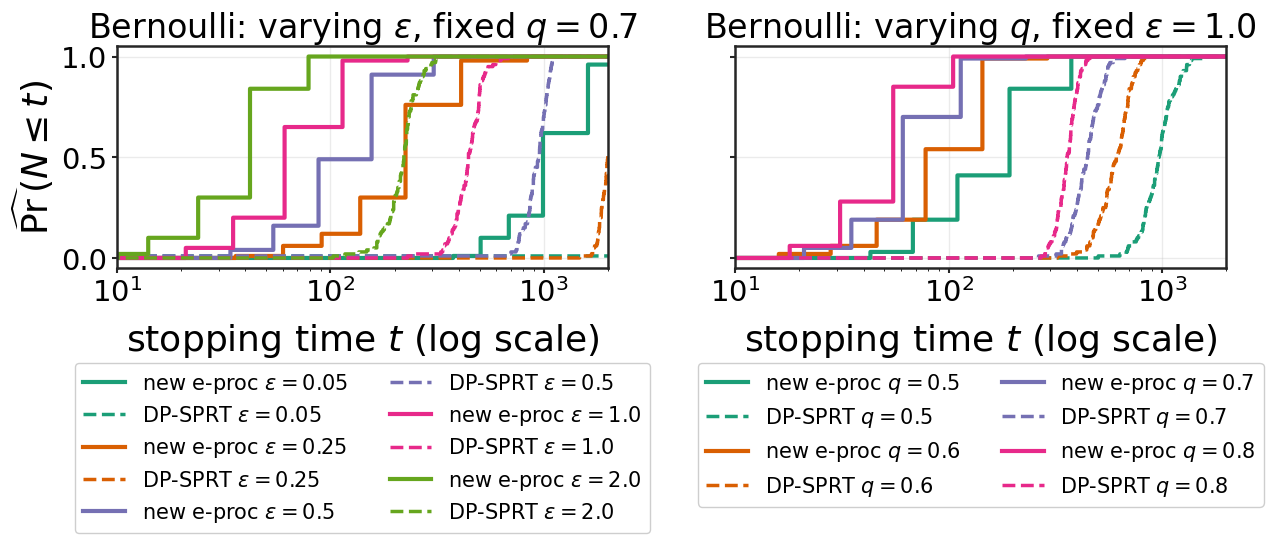

### Bernoulli new E* stopping-time summary: varying epsilon

| method | epsilon | q | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- |
| new two-sided private e-process | 0.05 | 0.7 | 1159.6 | 992.0 |
| DP-SPRT | 0.05 | 0.7 | 1981.0 | 2001.0 |
| new two-sided private e-process | 0.25 | 0.7 | 244.06 | 225.0 |
| DP-SPRT | 0.25 | 0.7 | 1932.46 | 1996.0 |
| new two-sided private e-process | 0.5 | 0.7 | 129.85 | 156.0 |
| DP-SPRT | 0.5 | 0.7 | 923.97 | 947.0 |
| new two-sided private e-process | 1.0 | 0.7 | 75.97 | 61.0 |
| DP-SPRT | 1.0 | 0.7 | 447.35 | 444.0 |
| new two-sided private e-process | 2.0 | 0.7 | 41.4 | 42.0 |
| DP-SPRT | 2.0 | 0.7 | 219.56 | 221.0 |

### Bernoulli new E* stopping-time summary: varying q

| method | epsilon | q | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- |
| new two-sided private e-process | 1.0 | 0.5 | 179.52 | 193.0 |
| DP-SPRT | 1.0 | 0.5 | 979.97 | 969.0 |
| new two-sided private e-process | 1.0 | 0.6 | 102.42 | 78.0 |
| DP-SPRT | 1.0 | 0.6 | 609.33 | 617.0 |
| new two-sided private e-process | 1.0 | 0.7 | 72.42 | 61.0 |
| DP-SPRT | 1.0 | 0.7 | 448.5 | 448.0 |
| new two-sided private e-process | 1.0 | 0.8 | 55.0 | 55.0 |
| DP-SPRT | 1.0 | 0.8 | 360.87 | 359.5 |

In [16]:
# ---------- Bernoulli: new E* two-sided private e-process vs corrected DP-SPRT ----------

# Experiment settings for this figure.
alpha = 0.05
beta = 0.05
T = 2_000
R = 100
c_private_new = 1.0
rho_private_new = 5.0
p0_bern = 0.3
q_fixed = 0.7
q_grid = [0.5, 0.6, 0.7, 0.8]
eps_grid = [0.05, 0.25, 0.5, 1.0, 2.0]
eps_fixed = 1.0

combined_title_fs = 24
combined_label_fs = 26
combined_tick_fs = 21
combined_legend_fs = 15

from IPython.display import Markdown, display


def df_to_markdown_table_bernoulli_new(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


bernoulli_new_summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_new_eprocess_bernoulli_taus_Q(
        p0_bern, q_fixed, ee, R, T, alpha, beta, c_private_new, rho_private_new,
        two_sided=True, seed=90_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_new_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "new two-sided private e-process",
        "epsilon": ee,
        "q": q_fixed,
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"new e-proc $\varepsilon={ee}$")

    taus_s = dpsprt_bernoulli_taus_Q(
        p0_bern, q_fixed, ee, R, T, alpha, beta,
        seed=100_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_new_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "DP-SPRT",
        "epsilon": ee,
        "q": q_fixed,
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $\varepsilon={ee}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $\varepsilon$, fixed $q={q_fixed}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=combined_label_fs)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

ax = axes[1]
for k, qq in enumerate(q_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_new_eprocess_bernoulli_taus_Q(
        p0_bern, qq, eps_fixed, R, T, alpha, beta, c_private_new, rho_private_new,
        two_sided=True, seed=110_000 + int(1000 * qq)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_new_summary_rows.append({
        "experiment": "varying q",
        "method": "new two-sided private e-process",
        "epsilon": eps_fixed,
        "q": qq,
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"new e-proc $q={qq}$")

    taus_s = dpsprt_bernoulli_taus_Q(
        p0_bern, qq, eps_fixed, R, T, alpha, beta,
        seed=120_000 + int(1000 * qq)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_new_summary_rows.append({
        "experiment": "varying q",
        "method": "DP-SPRT",
        "epsilon": eps_fixed,
        "q": qq,
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $q={qq}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $q$, fixed $\varepsilon={eps_fixed}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.43)
plt.savefig("bernoulli_new_e_star_dpsprt_vs_two_sided_eprocess_ecdf.pdf", bbox_inches="tight")
plt.show()

bernoulli_new_summary = pd.DataFrame(bernoulli_new_summary_rows)
for experiment_name, table_df in bernoulli_new_summary.groupby("experiment", sort=False):
    table_df = table_df[["method", "epsilon", "q", "mean stopping time", "median stopping time"]].copy()
    table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
    table_df["median stopping time"] = table_df["median stopping time"].round(2)
    display(Markdown(f"### Bernoulli new E* stopping-time summary: {experiment_name}"))
    display(Markdown(df_to_markdown_table_bernoulli_new(table_df)))


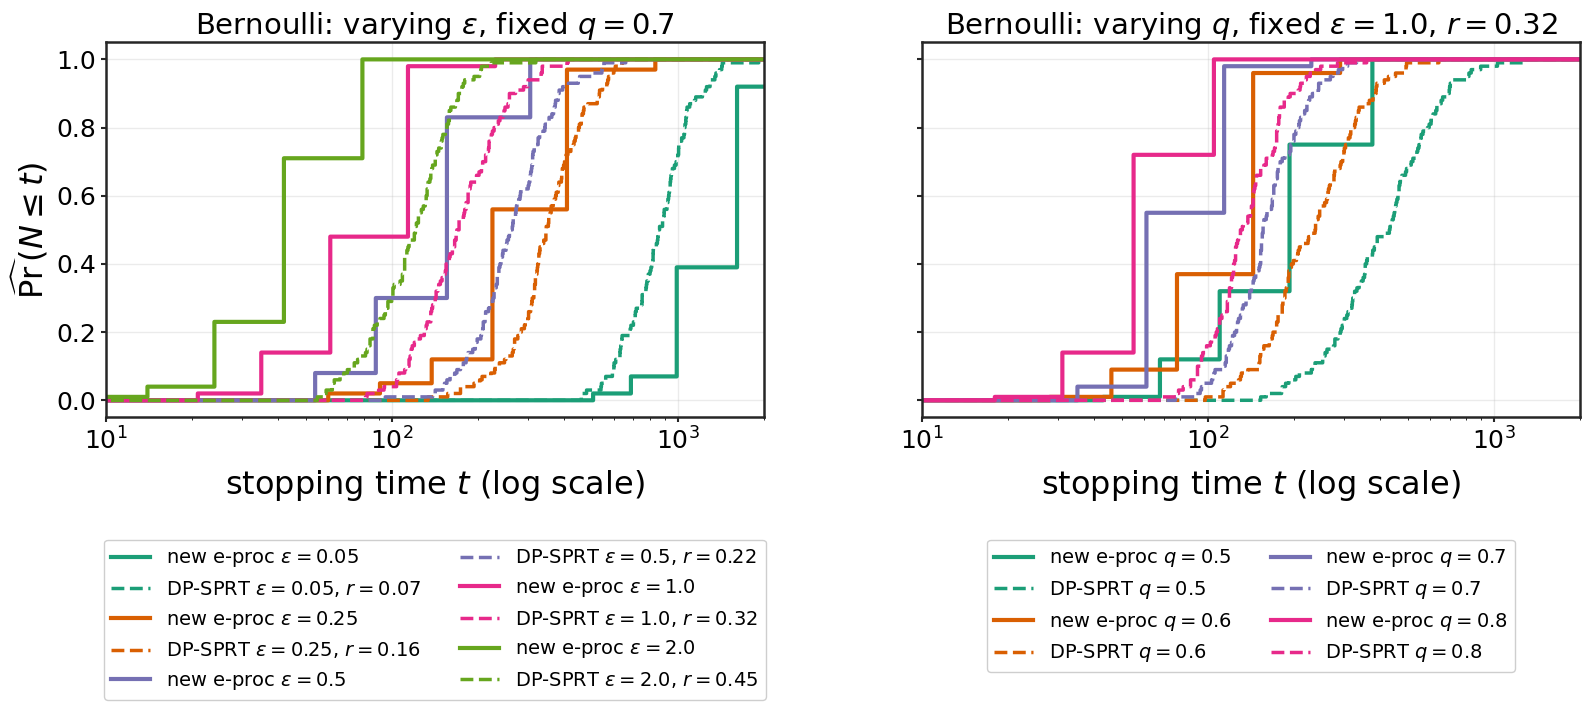

### Bernoulli new E* subsampled stopping-time summary: varying epsilon

| method | epsilon | q | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| new two-sided private e-process | 0.05 | 0.7 |  | 1376.3 | 1612.0 |
| subsampled DP-SPRT | 0.05 | 0.7 | 0.071 | 888.25 | 859.0 |
| new two-sided private e-process | 0.25 | 0.7 |  | 305.74 | 225.0 |
| subsampled DP-SPRT | 0.25 | 0.7 | 0.158 | 365.91 | 347.0 |
| new two-sided private e-process | 0.5 | 0.7 |  | 158.21 | 156.0 |
| subsampled DP-SPRT | 0.5 | 0.7 | 0.224 | 279.18 | 261.5 |
| new two-sided private e-process | 1.0 | 0.7 |  | 86.96 | 114.0 |
| subsampled DP-SPRT | 1.0 | 0.7 | 0.316 | 184.28 | 170.5 |
| new two-sided private e-process | 2.0 | 0.7 |  | 48.13 | 42.0 |
| subsampled DP-SPRT | 2.0 | 0.7 | 0.447 | 124.01 | 121.0 |

### Bernoulli new E* subsampled stopping-time summary: varying q

| method | epsilon | q | r | mean stopping time | median stopping time |
| --- | --- | --- | --- | --- | --- |
| new two-sided private e-process | 1.0 | 0.5 |  | 206.9 | 193.0 |
| subsampled DP-SPRT | 1.0 | 0.5 | 0.316 | 445.52 | 432.0 |
| new two-sided private e-process | 1.0 | 0.6 |  | 122.36 | 144.0 |
| subsampled DP-SPRT | 1.0 | 0.6 | 0.316 | 250.06 | 237.5 |
| new two-sided private e-process | 1.0 | 0.7 |  | 86.13 | 61.0 |
| subsampled DP-SPRT | 1.0 | 0.7 | 0.316 | 167.26 | 156.0 |
| new two-sided private e-process | 1.0 | 0.8 |  | 65.51 | 55.0 |
| subsampled DP-SPRT | 1.0 | 0.8 | 0.316 | 143.09 | 131.0 |

In [17]:
# ---------- Bernoulli: new E* two-sided private e-process vs subsampled DP-SPRT ----------

# Experiment settings for this figure.
alpha = 0.025
beta = 0.025
T = 2_000
R = 100
c_private_new = 1.0
rho_private_new = 5.0
p0_bern = 0.3
q_fixed = 0.7
q_grid = [0.5, 0.6, 0.7, 0.8]
eps_grid = [0.05, 0.25, 0.5, 1.0, 2.0]
eps_fixed = 1.0

combined_title_fs = 21
combined_label_fs = 23
combined_tick_fs = 18
combined_legend_fs = 14


def r_paper(eps):
    return min(1.0, np.sqrt(eps / 10.0))


def df_to_markdown_table_bernoulli(df):
    headers = list(df.columns)
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in headers) + " |")
    return "\n".join(lines)


from IPython.display import Markdown, display

bernoulli_summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

ax = axes[0]
for k, ee in enumerate(eps_grid):
    color = dark2[k % len(dark2)]
    rr = r_paper(ee)

    taus_e = private_new_eprocess_bernoulli_taus_Q(
        p0_bern, q_fixed, ee, R, T, alpha, beta, c_private_new, rho_private_new,
        two_sided=True, seed=90_000 + int(1000 * ee)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "new two-sided private e-process",
        "epsilon": ee,
        "q": q_fixed,
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"new e-proc $\varepsilon={ee}$")

    taus_s = dpsprt_bernoulli_subsampled_taus_Q(
        p0_bern, q_fixed, ee, rr, R, T, alpha, beta,
        seed=100_000 + int(1000 * ee) + int(10_000 * rr)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_summary_rows.append({
        "experiment": "varying epsilon",
        "method": "subsampled DP-SPRT",
        "epsilon": ee,
        "q": q_fixed,
        "r": round(rr, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(
        x, y, where="post", color=color, lw=2.5, ls="--",
        label=rf"DP-SPRT $\varepsilon={ee}$, $r={rr:.2f}$"
    )

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $\varepsilon$, fixed $q={q_fixed}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
ax.set_ylabel(r"$\widehat{\Pr}(N \leq t)$", fontsize=combined_label_fs)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

ax = axes[1]
r_fixed = r_paper(eps_fixed)
for k, qq in enumerate(q_grid):
    color = dark2[k % len(dark2)]

    taus_e = private_new_eprocess_bernoulli_taus_Q(
        p0_bern, qq, eps_fixed, R, T, alpha, beta, c_private_new, rho_private_new,
        two_sided=True, seed=110_000 + int(1000 * qq)
    )
    x, y = ecdf_values(taus_e, T)
    bernoulli_summary_rows.append({
        "experiment": "varying q",
        "method": "new two-sided private e-process",
        "epsilon": eps_fixed,
        "q": qq,
        "r": "",
        "mean stopping time": np.mean(taus_e),
        "median stopping time": np.median(taus_e),
    })
    ax.step(x, y, where="post", color=color, lw=3.0, label=rf"new e-proc $q={qq}$")

    taus_s = dpsprt_bernoulli_subsampled_taus_Q(
        p0_bern, qq, eps_fixed, r_fixed, R, T, alpha, beta,
        seed=120_000 + int(1000 * qq) + int(10_000 * r_fixed)
    )
    x, y = ecdf_values(taus_s, T)
    bernoulli_summary_rows.append({
        "experiment": "varying q",
        "method": "subsampled DP-SPRT",
        "epsilon": eps_fixed,
        "q": qq,
        "r": round(r_fixed, 3),
        "mean stopping time": np.mean(taus_s),
        "median stopping time": np.median(taus_s),
    })
    ax.step(x, y, where="post", color=color, lw=2.5, ls="--", label=rf"DP-SPRT $q={qq}$")

ax.set_xscale("log")
ax.set_xlim(10, T)
ax.set_title(rf"Bernoulli: varying $q$, fixed $\varepsilon={eps_fixed}$, $r={r_fixed:.2f}$", fontsize=combined_title_fs)
ax.set_xlabel("stopping time $t$ (log scale)", fontsize=combined_label_fs, labelpad=10)
style_axis(ax)
ax.tick_params(axis="both", labelsize=combined_tick_fs)
ax.legend(
    fontsize=combined_legend_fs,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=True,
    edgecolor="0.8",
    facecolor="white",
    framealpha=0.95,
)

#fig.suptitle(r"Subsampled DP-SPRT with $r(\varepsilon)=\min(1,\sqrt{\varepsilon/10})$", fontsize=combined_title_fs + 1, y=0.98)
plt.tight_layout()
fig.subplots_adjust(bottom=0.34, top=0.84, wspace=0.24)
plt.savefig("bernoulli_new_e_star_subsampled_dpsprt_vs_two_sided_eprocess_ecdf_paper_r.pdf", bbox_inches="tight")
plt.show()

bernoulli_summary = pd.DataFrame(bernoulli_summary_rows)
for experiment_name, table_df in bernoulli_summary.groupby("experiment", sort=False):
    table_df = table_df[["method", "epsilon", "q", "r", "mean stopping time", "median stopping time"]].copy()
    table_df["mean stopping time"] = table_df["mean stopping time"].round(2)
    table_df["median stopping time"] = table_df["median stopping time"].round(2)
    display(Markdown(f"### Bernoulli new E* subsampled stopping-time summary: {experiment_name}"))
    display(Markdown(df_to_markdown_table_bernoulli(table_df)))
